# 03 - Peer analysis: margins, returns and what drives ROE

A financial-analyst view of the 12-company universe using FinSight's own tested analytics
(`finsight.analytics`): margin trends, DuPont decomposition with driver attribution, peer
percentiles and growth. Every figure comes from the XBRL fact store.

*Skills shown: ratio analysis, DuPont, peer benchmarking, data visualisation.*

In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold", "axes.titlesize": 12,
})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

import math
from finsight.analytics.dupont import attribute_change, dupont_3
from finsight.analytics.peers import peer_table
from finsight.analytics.ratios import RATIOS, RatioError, compute_ratio
from finsight.analytics.trends import series_cagr
from finsight.config.settings import get_settings
from finsight.config.universe import load_universe
from finsight.ingestion.xbrl.store import FactStore

s = get_settings()
universe = load_universe(s.configs_dir / "universe.yaml")
store = FactStore(s.fact_db_path)
YEARS = list(universe.fiscal_years)

def value(t, metric, y):
    f = store.get_fact(t, metric, y)
    return None if f is None else f.value

def ratio(t, name, y):
    spec = RATIOS[name]
    try:
        cur = {m: value(t, m, y) for m in spec.inputs}
        prior = {m: value(t, m, y - 1) for m in spec.prior_inputs}
        if any(v is None for v in (*cur.values(), *prior.values())):
            return None
        return compute_ratio(name, cur, prior)
    except RatioError:
        return None

def frame(name):
    return pd.DataFrame({t: {y: ratio(t, name, y) for y in YEARS} for t in universe.tickers})

## 1. Profitability across the universe

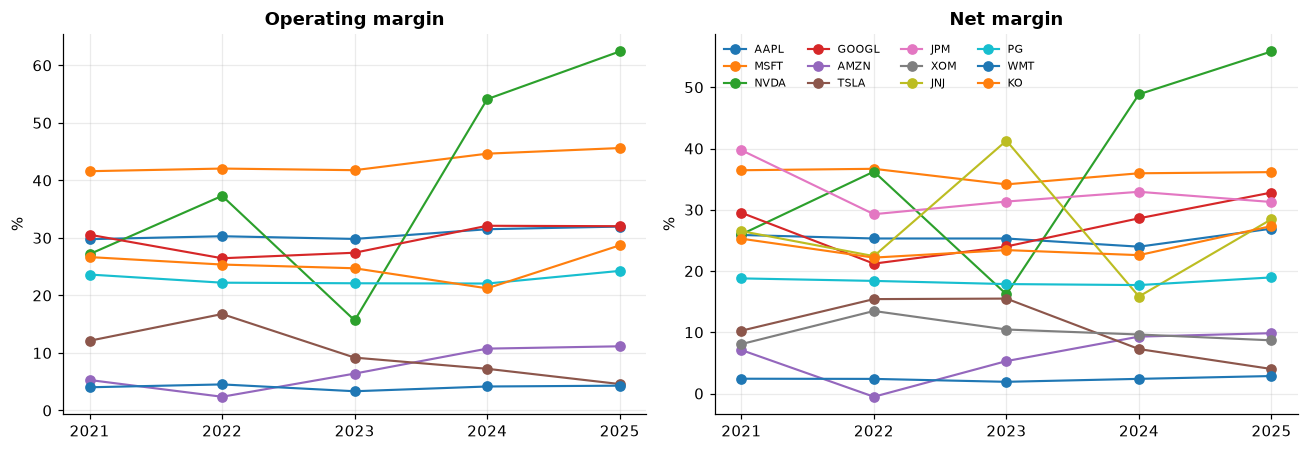

net margin FY2025, best to worst:
NVDA     55.8
MSFT     36.1
GOOGL    32.8
JPM      31.3
JNJ      28.5
KO       27.3
AAPL     26.9
PG       19.0
AMZN      9.9
XOM       8.7
TSLA      4.0
WMT       2.9


In [2]:
op, net = frame("operating_margin"), frame("net_margin")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for ax, data, title in [(axes[0], op, "Operating margin"), (axes[1], net, "Net margin")]:
    for t in data.columns:
        ax.plot(data.index, data[t] * 100, marker="o", lw=1.4, label=t)
    ax.set_title(title); ax.set_ylabel("%"); ax.set_xticks(YEARS)
axes[1].legend(ncol=4, fontsize=7, frameon=False, loc="upper left")
plt.tight_layout(); plt.show()
latest = net.loc[max(YEARS)].dropna().sort_values(ascending=False)
print("net margin FY%d, best to worst:" % max(YEARS)); print((latest * 100).round(1).to_string())

## 2. Peer ranking with percentiles (FY2024 return on equity)

ROE here is `net income / year-end parent shareholders' equity` - a definition stated explicitly because Apple's buybacks make it huge while a bank's is modest.

,ticker,ROE %,rank,percentile,vs median (pp)
0,AAPL,164.6,1,100,139.5
1,NVDA,69.2,2,91,44.2
2,KO,42.8,3,82,17.7
3,MSFT,32.8,4,73,7.8
4,GOOGL,30.8,5,64,5.7
5,PG,29.4,6,55,4.4
6,AMZN,20.7,7,45,-4.4
7,JNJ,19.7,8,36,-5.4
8,WMT,18.5,9,27,-6.6
9,JPM,17.0,10,18,-8.1


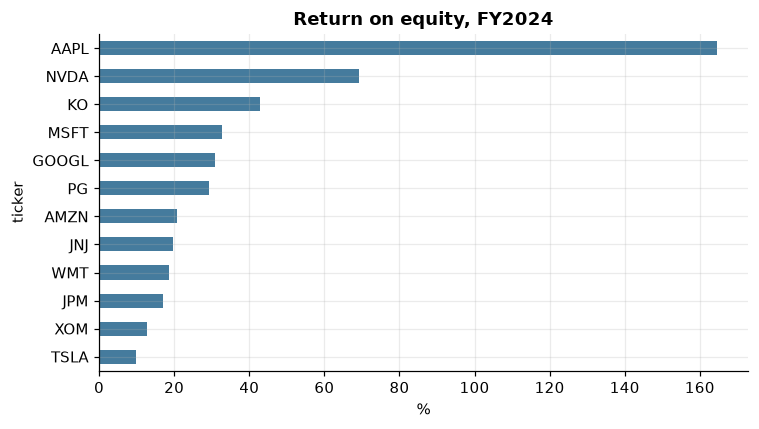

In [3]:
roe = {t: ratio(t, "roe", 2024) for t in universe.tickers}
roe = {t: v for t, v in roe.items() if v is not None}
rows = peer_table(roe)
tbl = pd.DataFrame([{"ticker": r.ticker, "ROE %": round(r.value * 100, 1), "rank": r.rank, "percentile": round(r.percentile), "vs median (pp)": round(r.vs_median * 100, 1)} for r in rows])
display(tbl)
ax = tbl.set_index("ticker")["ROE %"][::-1].plot.barh(figsize=(7, 4), color="#457b9d")
ax.set_title("Return on equity, FY2024"); ax.set_xlabel("%")
plt.tight_layout(); plt.show()

## 3. DuPont: *why* did ROE move?

ROE = net margin x asset turnover x equity multiplier. Because it is a product, the change decomposes **exactly** into per-factor log contributions - the analyst's answer to 'what drove it'.

,net_margin,asset_turnover,equity_multiplier,ROE before %,ROE after %
case,,,,,
AAPL FY2023->FY2024,-0.054,-0.015,0.122,156.076,164.594
MSFT FY2023->FY2024,0.052,-0.072,-0.046,35.089,32.828
NVDA FY2024->FY2025,0.134,0.232,-0.083,69.245,91.873
KO FY2023->FY2024,-0.036,-0.001,0.071,41.301,42.770


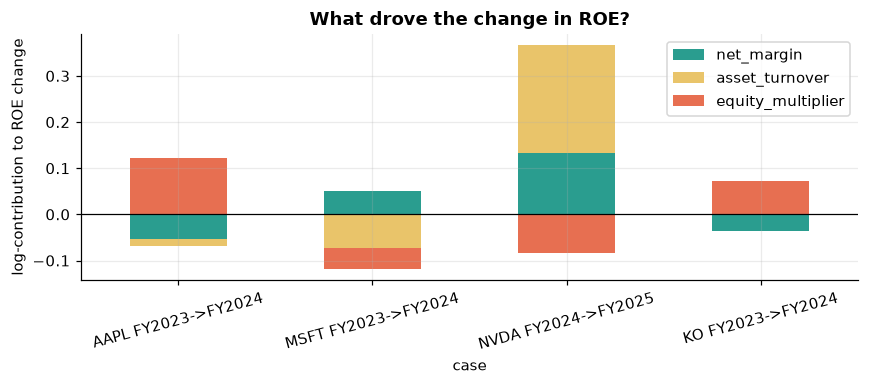

In [4]:
def dp(t, y):
    ni, rev, assets, eq = (value(t, m, y) for m in ("net_income", "revenue", "total_assets", "shareholders_equity"))
    return dupont_3(ni, rev, assets, eq)

cases = [("AAPL", 2023, 2024), ("MSFT", 2023, 2024), ("NVDA", 2024, 2025), ("KO", 2023, 2024)]
recs = []
for t, y0, y1 in cases:
    try:
        contrib = attribute_change(dp(t, y0), dp(t, y1))
    except RatioError:
        continue
    total = math.log(dp(t, y1).roe / dp(t, y0).roe)
    assert abs(sum(contrib.values()) - total) < 1e-9          # the decomposition is exact
    recs.append({"case": f"{t} FY{y0}->FY{y1}", **{k: v for k, v in contrib.items()}, "ROE before %": dp(t, y0).roe * 100, "ROE after %": dp(t, y1).roe * 100})
dfc = pd.DataFrame(recs).set_index("case")
display(dfc.round(3))
ax = dfc[["net_margin", "asset_turnover", "equity_multiplier"]].plot.bar(stacked=True, figsize=(8, 3.6), color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("log-contribution to ROE change"); ax.set_title("What drove the change in ROE?")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 4. Growth: revenue CAGR FY2021-FY2025

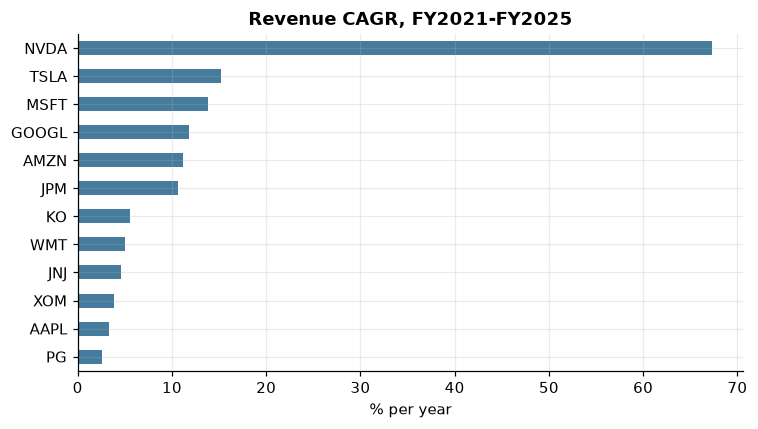

NVDA     67.3
TSLA     15.2
MSFT     13.8
GOOGL    11.8
AMZN     11.1
JPM      10.7
KO        5.5
WMT       5.1
JNJ       4.6
XOM       3.9
AAPL      3.3
PG        2.6


In [5]:
cagr = {}
for t in universe.tickers:
    series = {y: value(t, "revenue", y) for y in YEARS if value(t, "revenue", y)}
    if len(series) >= 2:
        cagr[t] = series_cagr(series)
g = pd.Series(cagr).sort_values(ascending=False) * 100
ax = g[::-1].plot.barh(figsize=(7, 4), color="#457b9d")
ax.set_title("Revenue CAGR, FY2021-FY2025"); ax.set_xlabel("% per year")
plt.tight_layout(); plt.show()
print(g.round(1).to_string())

## Findings

* Margin dispersion is **structural** (software and consumer brands vs. retail and energy), not cyclical.
* The DuPont attribution above shows **the same headline can have opposite causes**. Apple's FY2024 ROE
  rose because of the *equity-multiplier* term (shrinking equity from buybacks) while its margin and turnover
  actually fell - a capital-structure effect. NVIDIA's FY2025 jump was *operational* (margin and turnover
  both up) with leverage a drag. Ranking companies on ROE alone would hide that difference.
* The attribution is exact by construction - a property tested in `tests/unit/analytics` with
  property-based tests, not just here.